# Load Data

In [1]:
import pandas as pd
import numpy as np
import shap
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import lifetimes as lt
from xgboost import XGBClassifier


In [2]:
# Load data
transactions = pd.read_csv('data/transactions.csv', parse_dates=['transaction_date'])
customers = pd.read_csv('data/customers.csv', parse_dates=['signup_date'])

print(f"Transactions: {len(transactions)} rows")
print(f"There are {len(customers)} customers, but only {transactions['customer_id'].nunique()} who have made transactions")
transactions.head()

Transactions: 46704 rows
There are 3000 customers, but only 2892 who have made transactions


,customer_id,transaction_date,amount
0,C00000,2025-09-10,195.78
1,C00000,2025-09-12,50.87
2,C00000,2025-10-01,133.25
3,C00000,2025-10-16,37.44
4,C00000,2025-10-18,101.95


In [3]:
print(customers.dtypes)
print(transactions.dtypes)

customer_id                   object
signup_date           datetime64[ns]
true_lifetime_days             int64
dtype: object
customer_id                 object
transaction_date    datetime64[ns]
amount                     float64
dtype: object


# RFM Analysis

In [4]:
# Use the day after the last transaction as the analysis date (aka 01-01-2026)
analysis_date = transactions['transaction_date'].max() + pd.Timedelta(days=1)
print(f"Analysis date: {analysis_date}")

# RFM per customer
rfm = transactions.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (analysis_date - x.max()).days),
    frequency=('transaction_date', 'count'),
    monetary=('amount', 'sum')        
).reset_index()

rfm.head()

Analysis date: 2026-01-01 00:00:00


,customer_id,recency,frequency,monetary
0,C00000,1,12,1222.85
1,C00001,12,19,1228.46
2,C00002,97,11,910.64
3,C00003,44,4,114.71
4,C00004,109,19,2018.94


In [5]:
rfm_q = rfm.copy()

# use qcut to divide into 5 quantiles
# Recency: more recent is higher score
rfm_q["R_score"] = pd.qcut(
    rfm_q["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)
# Frequency: higher is better
rfm_q["F_score"] = pd.qcut(
    rfm_q["frequency"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary: higher is better
rfm_q["M_score"] = pd.qcut(
    rfm_q["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

def rfm_segment_rules(rfm_q):
    r = rfm_q['R_score']
    f = rfm_q['F_score']

    # High R, High F
    if r >= 4 and f >= 4:
        return "Champions"

    # Mid R, High F
    if 2 <= r < 4 and f >= 3:
        return "Loyal Customers"

    # Low R, High F
    if r <= 2 and f >= 4:
        return "Cannot Lose Them"

    # Low R, Mid F
    if r <= 2 and 2 <= f <= 4:
        return "At Risk"

    # Low R, Low F
    if r <= 2 and f <= 2:
        return "Hibernating"

    # Mid-low R, Mid F
    if 2 <= r <= 3 and 2 <= f <= 3:
        return "Need Attention"

    # Mid-low R, Low F
    if 2 <= r <= 3 and f <= 2:
        return "About To Sleep"

    # Mid-high/High R, Mid F
    if r >= 3 and 1 <= f <= 3:
        return "Potential Loyalists"

    # Mid-high R, Low F
    if 3 <= r <= 4 and f <= 1:
        return "Promising"

    # High R, Low F
    if r >= 4 and f <= 1:
        return "New Customers"

    return "Others"

rfm_q['segment'] = rfm_q.apply(rfm_segment_rules, axis=1)

rfm_q

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,segment
0,C00000,1,12,1222.85,5,3,4,Potential Loyalists
1,C00001,12,19,1228.46,4,4,4,Champions
2,C00002,97,11,910.64,2,3,4,Loyal Customers
3,C00003,44,4,114.71,3,1,1,About To Sleep
4,C00004,109,19,2018.94,2,4,5,Loyal Customers
...,...,...,...,...,...,...,...,...
2887,C02995,1,15,460.70,5,4,3,Champions
2888,C02996,34,9,638.36,3,3,3,Loyal Customers
2889,C02997,6,16,459.83,4,4,3,Champions
2890,C02998,1,24,1505.03,5,4,5,Champions


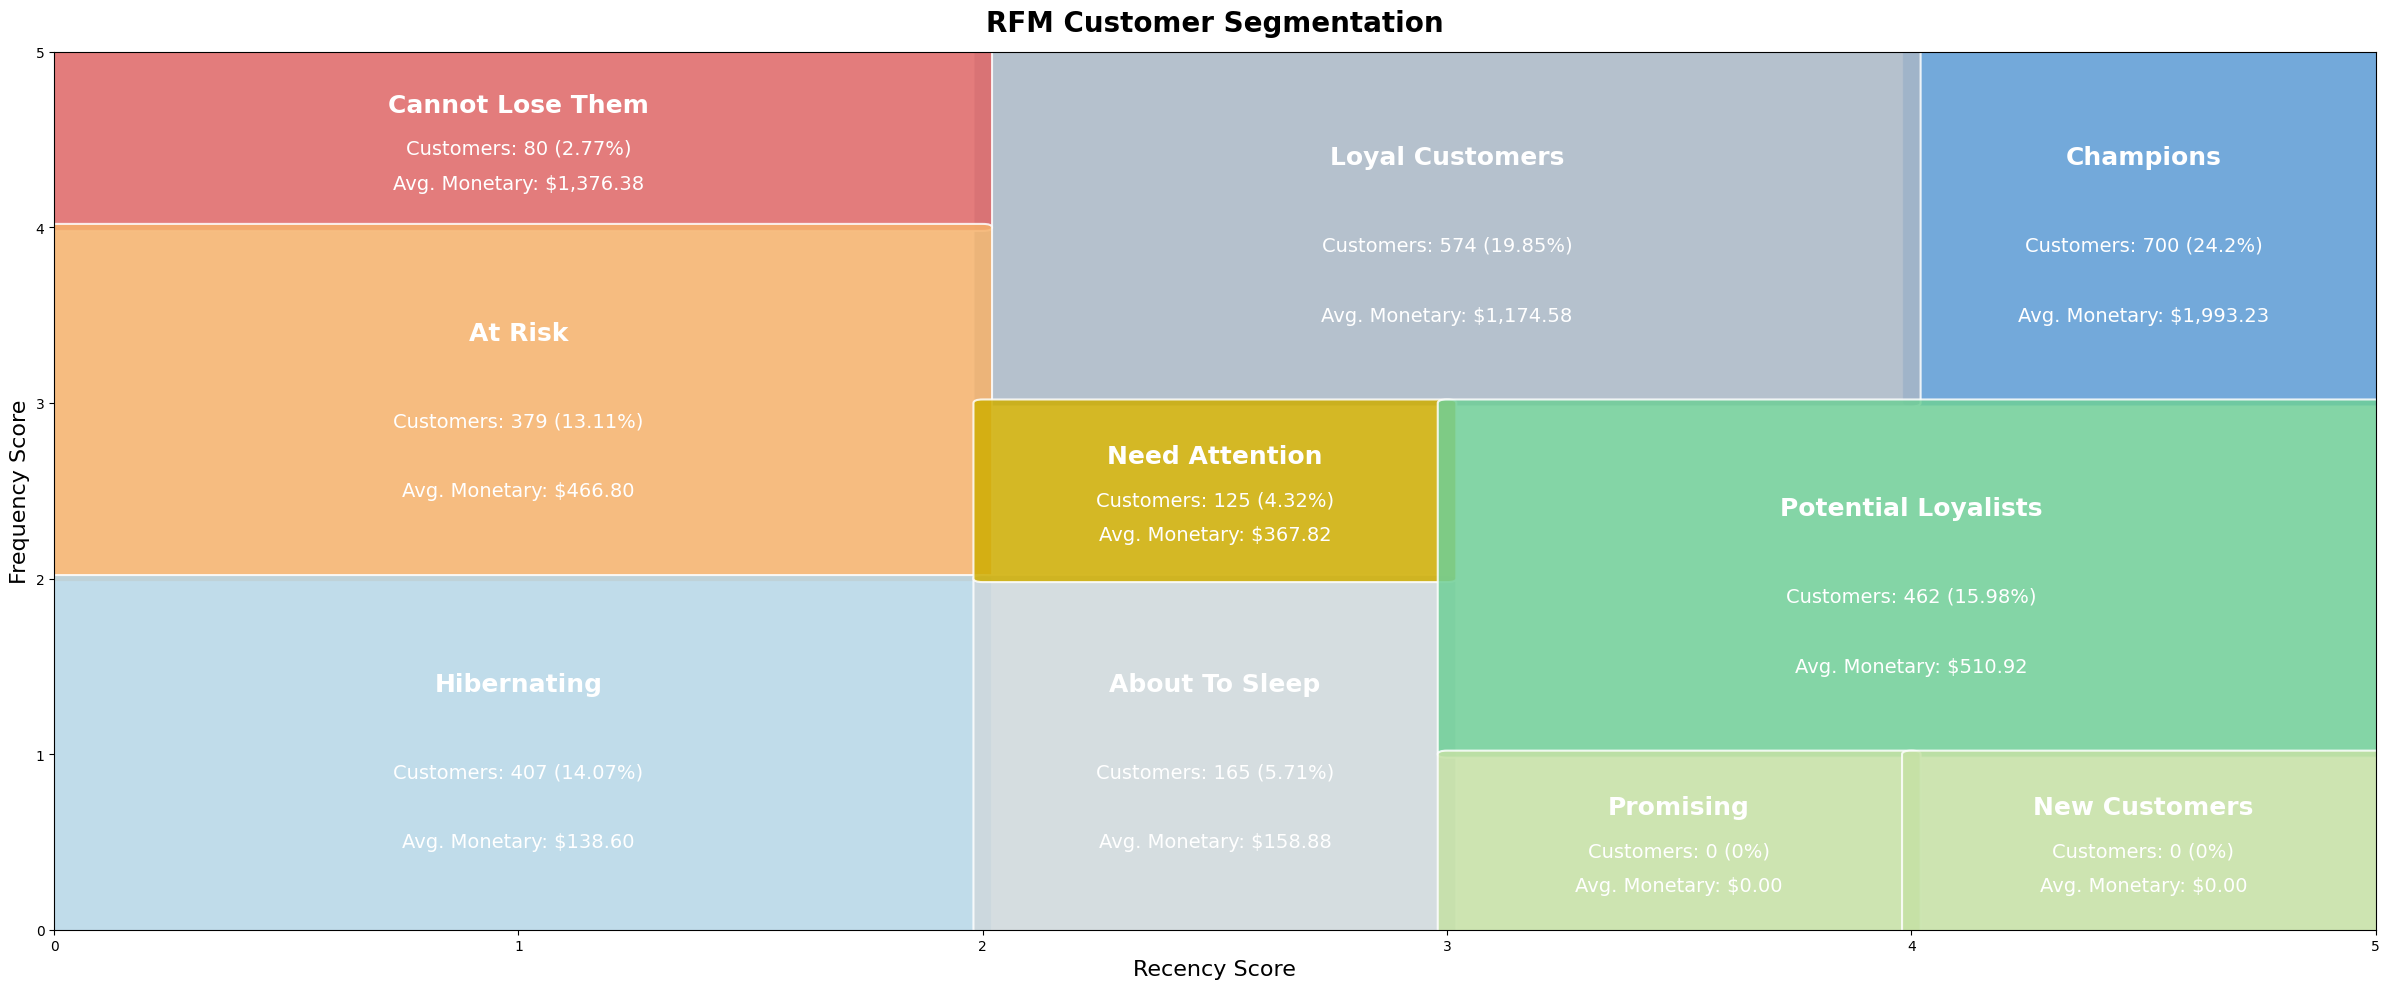

In [6]:
# ── RFM Heatmap Visualization ──

# Compute stats per segment
seg_stats = rfm_q.groupby('segment').agg(
    count=('customer_id', 'count'),
    avg_monetary=('monetary', 'mean')
).reset_index()
total_customers = len(rfm)
seg_stats['pct'] = (seg_stats['count'] / total_customers * 100).round(2)
seg_stats = seg_stats.set_index('segment')

# Grid layout: each segment -> (x, y, width, height) in R x F coordinates
# x = Recency Score (left edge), y = Frequency Score (bottom edge)
grid = {
    'Champions':         (4, 3, 1, 2),
    'Loyal Customers':   (2, 3, 2, 2),
    'Cannot Lose Them':  (0, 4, 2, 1),
    'At Risk':           (0, 2, 2, 2),
    'Hibernating':       (0, 0, 2, 2),
    'About To Sleep':    (2, 0, 1, 2),
    'Need Attention':    (2, 2, 1, 1),
    'Potential Loyalists': (3, 1, 2, 2),
    'Promising':         (3, 0, 1, 1),
    'New Customers':     (4, 0, 1, 1),
}

# Color palette for segments
colors = {
    'Champions':          '#5B9BD5',
    'Loyal Customers':    '#A9B7C6',
    'Cannot Lose Them':   '#E06666',
    'At Risk':            '#F6B26B',
    'Hibernating':        '#B6D7E8',
    'About To Sleep':     '#CFD8DC',
    'Need Attention':     '#CEAD00',
    'Potential Loyalists':'#6FCF97',
    'Promising':          '#C5E1A5',
    'New Customers':      '#C5E1A5',
}

fig, ax = plt.subplots(figsize=(24, 10))

for seg, (x, y, w, h) in grid.items():
    color = colors.get(seg, '#DDDDDD')
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1.5, edgecolor='white', facecolor=color, alpha=0.85
    )
    ax.add_patch(rect)

    # Get stats
    if seg in seg_stats.index:
        count = seg_stats.loc[seg, 'count']
        pct = seg_stats.loc[seg, 'pct']
        avg_m = seg_stats.loc[seg, 'avg_monetary']
    else:
        count, pct, avg_m = 0, 0, 0

    cx, cy = x + w / 2, y + h / 2
    ax.text(cx, cy + h * 0.2, seg, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(cx, cy - h * 0.05, f"Customers: {count:,} ({pct}%)",
            ha='center', va='center', fontsize=14, color='white')
    ax.text(cx, cy - h * 0.25, f"Avg. Monetary: ${avg_m:,.2f}",
            ha='center', va='center', fontsize=14, color='white')

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel('Recency Score', fontsize=16)
ax.set_ylabel('Frequency Score', fontsize=16)
ax.set_title('RFM Customer Segmentation', fontsize=20, fontweight='bold', pad=15)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.grid(False)
ax.set_facecolor('#FAFAFA')
fig.tight_layout()
plt.show()

Hibernating customers make infrequent purchases and haven't bought in a long time, making them at high risk for churn. As a business, it's better to prioritize champions and focus on converting potential loyalists into loyal customers or champions, rather than targeting hibernating customers.

# Churn Classification

Because the dataset covers only one year, we will set the churn labeling cutoff date to 2025-09-01 and use a 60-day prediction window.

## Churn Labelling

In [7]:
prediction_window = 90
cutoff_date = pd.Timestamp('2025-12-31') - pd.Timedelta(days=prediction_window)

# function to create churn labels
def create_churn_labels(df, cutoff_date, prediction_window):
    future = df[(df['transaction_date'] > cutoff_date) & (df['transaction_date'] <= cutoff_date + pd.Timedelta(days=prediction_window))]
    active_customers = future['customer_id'].unique()
    labels = (
        df[df["transaction_date"] <= cutoff_date]
        [["customer_id"]]
        .drop_duplicates()
    )
    labels["churn"] = ~labels["customer_id"].isin(active_customers)
    
    return labels.reset_index(drop=True)

churn_labels = create_churn_labels(transactions, cutoff_date, prediction_window)

# check for data imbalance
print(churn_labels['churn'].value_counts())

churn_labels.head()

churn
True     1167
False    1097
Name: count, dtype: int64


,customer_id,churn
0,C00000,False
1,C00001,False
2,C00002,True
3,C00004,True
4,C00006,False


--> Since churn is roughly split between True and False (about 50/50), class imbalance is not a major concern for this dataset

In [8]:
# feature engineering for churn classification
def create_churn_features(df, cutoff_date):
    hist = df[df["transaction_date"] <= cutoff_date]

    agg = hist.groupby('customer_id').agg(
        # rfm
        recency=('transaction_date', lambda x: (cutoff_date - x.max()).days),
        frequency=('transaction_date', 'count'),
        monetary=('amount', 'sum'),
        # change in activity trend
        freq_30d = ('transaction_date', lambda x: (x >= cutoff_date - pd.Timedelta(days=30)).sum()),
        freq_90d = ('transaction_date', lambda x: (x >= cutoff_date - pd.Timedelta(days=90)).sum()),
        amount_30d = ('amount', lambda s: s[hist.loc[s.index, 'transaction_date'] >= cutoff_date - pd.Timedelta(days=30)].sum()),
        amount_90d = ('amount', lambda s: s[hist.loc[s.index, 'transaction_date'] >= cutoff_date - pd.Timedelta(days=90)].sum()),
        freq_past_90d_to_cutoff = ('transaction_date', lambda x: (x >= cutoff_date - pd.Timedelta(days=90)).sum()),
        freq_past_270d_to_180d = ('transaction_date', lambda x: ((x >= cutoff_date - pd.Timedelta(days=270)) & (x < cutoff_date - pd.Timedelta(days=180))).sum()),
        # gap between transactions
        max_gap=('transaction_date', lambda x: x.sort_values().diff().dt.days.max())
        )
        
    agg['freq30/90'] = agg['freq_30d'] / (agg['freq_90d'] + 1e-6)
    agg['amount30/90'] = agg['amount_30d'] / (agg['amount_90d'] + 1e-6)
    # compare total # transactions from 90d to cutoff vs from 270d to 180d
    agg['subtraction_90_270'] = agg['freq_past_90d_to_cutoff'] - agg['freq_past_270d_to_180d']
    
    return agg.reset_index()

features = create_churn_features(transactions, cutoff_date)

data = features.merge(churn_labels, on='customer_id')

In [9]:
train = data[data['customer_id'].isin(data['customer_id'].sample(frac=0.7, random_state=42))]
test = data[~data['customer_id'].isin(train['customer_id'])]

X_train = train.drop(columns=['customer_id', 'churn'])
y_train = train['churn'].astype(int)
X_test = test.drop(columns=['customer_id', 'churn'])
y_test = test['churn']

## Light GBM

In [10]:
lgbm = LGBMClassifier(
    objective='binary',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    metric='average_precision'
)

lgbm.fit(X_train, y_train)

def evaluate(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    return {
        "AUC": roc_auc_score(y, proba),
        "PR_AUC": average_precision_score(y, proba)
    }


print(evaluate(lgbm, X_test, y_test))

[LightGBM] [Info] Number of positive: 790, number of negative: 795
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1607
[LightGBM] [Info] Number of data points in the train set: 1585, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498423 -> initscore=-0.006309
[LightGBM] [Info] Start training from score -0.006309
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

## XG Boost

In [11]:
xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='aucpr'
)

xgb.fit(X_train, y_train)


print(evaluate(xgb, X_test, y_test))


{'AUC': 0.9365591020078347, 'PR_AUC': 0.9561626156514509}


## Confusion Matrix for LGBM

Best F1 threshold: 0.340  →  F1: 0.883


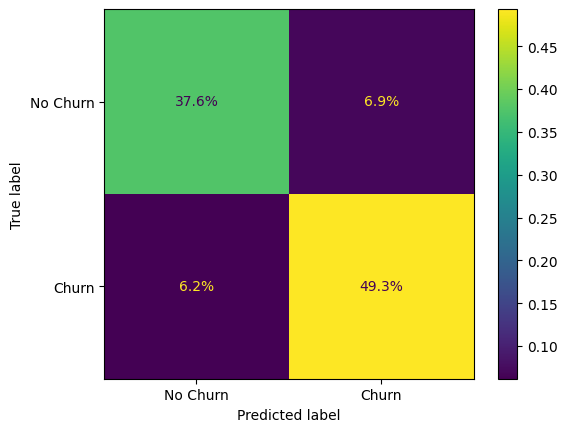

In [12]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (lgbm.predict_proba(X_test)[:,1] >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best F1 threshold: {best_threshold:.3f}  →  F1: {max(f1_scores):.3f}")
####

lgbm_pred = (lgbm.predict_proba(X_test)[:,1] >= best_threshold).astype(int)
# display matrix
cm = confusion_matrix(y_test, lgbm_pred, normalize='all')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot(values_format='.1%')
plt.show()


# Feature Explanation with SHAP

/Users/hoangntmbee/Downloads/survival_analysis/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


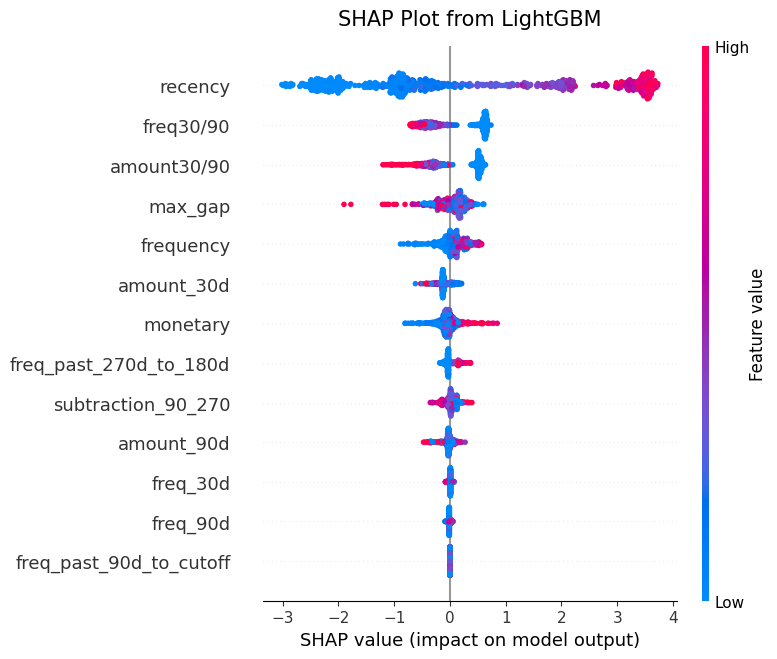

In [13]:
explainer = shap.TreeExplainer(lgbm)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Plot from LightGBM", size=15, pad=15)
plt.tight_layout()
plt.show()

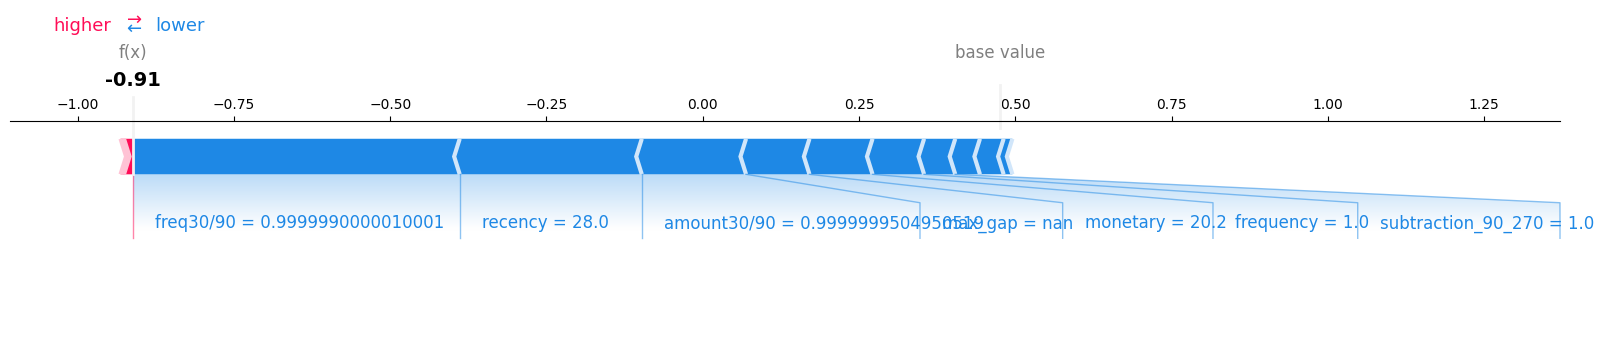

In [14]:
idx=1 # y_test: no churn

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

**log-odds** = -0.91 → Churn Probability = 28.70%
 
$$p = \frac{1}{1 + e^{-(\text{log-odds})}} = \frac{1}{1 + e^{0.91}} = \frac{1}{1 + 2.484} = \frac{1}{3.484} \approx 0.287$$

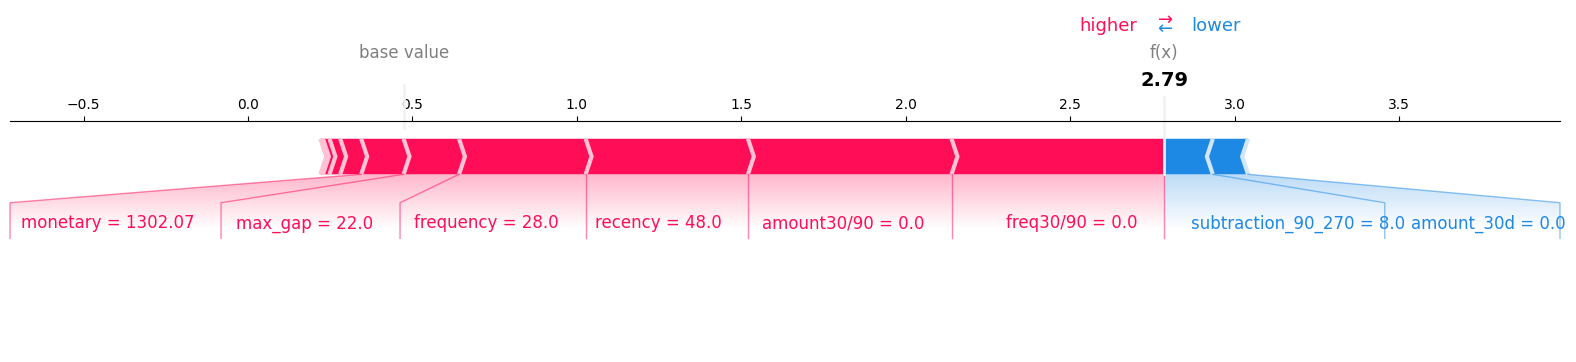

In [15]:
idx=3 # y_test: churn

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

**log-odds** = 2.79 → Churn Probability = 94.21%

$$p = \frac{1}{1 + e^{-(\text{log-odds})}} = \frac{1}{1 + e^{-2.79}} = \frac{1}{1 + 0.061} = \frac{1}{1.061} \approx 0.942$$

# BG-NBD + Gamma-Gamma

We use the same cutoff_date from the classification model to split the data into calibration and holdout periods

Notes: <p/>
Dropout Rate: Beta(a, b) to  model distribution of dropout probability for the whole population -> Geometric to model when dropout happens for a specific person given p -> p(alive) <p/>

Purchase Rate: NBD, e.g. Gamma (parameterised by r and alpha) + Poisson, to model purchase rate lambda (λ) on the whole population and get prediction of purchases in N amount of time --> then use Gamma-Gamma to calculate how much each transaction is worth on average

## Lifetime Summary Dataframe

In [16]:
lifetime_df = (
    lt.utils.summary_data_from_transaction_data(
        transactions,
        customer_id_col='customer_id',
        datetime_col='transaction_date',
        monetary_value_col='amount', # for Gamma Gamma Fitter later
        observation_period_end=cutoff_date,  # to compare with the classification model
        freq='D'
    )
)

lifetime_df.head()

,frequency,recency,T,monetary_value
customer_id,,,,
C00000,2.0,21.0,22.0,92.060000
C00001,9.0,178.0,199.0,61.631111
C00002,9.0,37.0,43.0,86.307778
C00004,17.0,98.0,116.0,109.965882
C00006,0.0,0.0,28.0,0.000000


- frequency: Number of repeat transactions (first purchase excluded)
- recency: Time between first and last purchase within the calibration period (not the same as RFM)
- T (age): Time from first purchase to the end of the calibration period

## BG Fitting and P-alive chart

In [17]:
# Beta Geometric Fitter (BG-NBD)
bg = lt.BetaGeoFitter(penalizer_coef=0.001)
bg.fit(
    frequency=lifetime_df['frequency'],
    recency=lifetime_df['recency'],
    T=lifetime_df['T']
)

print(bg.summary)



            coef  se(coef)  lower 95% bound  upper 95% bound
r       1.843978  0.071687         1.703471         1.984485
alpha  16.111618  0.699011        14.741556        17.481679
a       0.403398  0.022780         0.358750         0.448047
b       4.332786  0.285393         3.773414         4.892157


The P(alive) chart below starts from the customer's **first transaction date** and shows how the estimated probability of being alive evolves over time, with red dashed lineThe P(alive) chart below starts from the customer’s first transaction date and shows how the estimated probability of being active evolves over time. The probability is updated based on observed purchase behavior, increasing after transactions and gradually decreasing during periods of inactivity. Red dashed lines mark each purchase events.

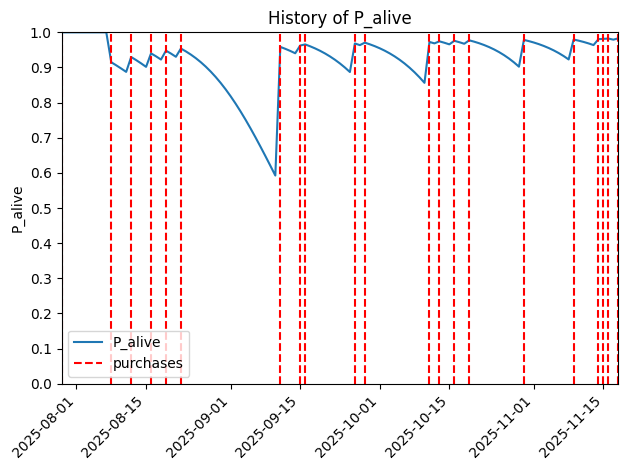

In [18]:
# p-alive chart
from lifetimes import plotting

id = 'C01329'
customer_transactions = (
    transactions[transactions['customer_id'] == id]
    .assign(transaction_date=lambda x: x['transaction_date'].astype('datetime64[ns]'))
)

ax = plotting.plot_history_alive(
    bg,
    t=90,
    transactions=customer_transactions,
    datetime_col='transaction_date'
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## Gamma-Gamma Fitting and CLV Prediction

In [19]:
# Gamma Gamma Fitter 
gg = lt.GammaGammaFitter(penalizer_coef=0.01)

lifetime_df_ggf = lifetime_df[lifetime_df['monetary_value'] > 0]

gg.fit(
    frequency=lifetime_df_ggf['frequency'],
    monetary_value=lifetime_df_ggf['monetary_value']
)

lifetime_df.loc[lifetime_df_ggf.index, 'expected_avg_order_value'] = (
    gg.conditional_expected_average_profit(
        lifetime_df_ggf['frequency'],
        lifetime_df_ggf['monetary_value']
    )
)

# prediction of purchase count in next 3 months
lifetime_df['predicted_purchases_3M'] = bg.predict(
    t=90,
    frequency=lifetime_df['frequency'],
    recency=lifetime_df['recency'],
    T=lifetime_df['T']
)


lifetime_df['CLV_3M'] = gg.customer_lifetime_value(
    bg,
    lifetime_df_ggf['frequency'],
    lifetime_df_ggf['recency'],
    lifetime_df_ggf['T'],
    lifetime_df_ggf['monetary_value'],
    time=3, # 3 months
    discount_rate=0.01, # 1% discount rate
    freq='D'
)

lifetime_df = lifetime_df.sort_values(by='CLV_3M', ascending=False)

lifetime_df.tail(2000)

,frequency,recency,T,monetary_value,expected_avg_order_value,predicted_purchases_3M,CLV_3M
customer_id,,,,,,,
C01329,10.0,61.0,65.0,74.235000,75.219607,10.738044,792.292971
C01022,1.0,6.0,14.0,132.420000,148.150269,5.414626,787.123783
C00701,9.0,52.0,54.0,69.410000,70.461351,11.300068,781.064273
C00011,5.0,32.0,33.0,80.036000,82.116504,9.690950,780.744510
C02010,16.0,85.0,86.0,58.223125,58.755482,13.504670,778.268270
...,...,...,...,...,...,...,...
C02935,0.0,0.0,195.0,0.000000,NaN,0.750127,NaN
C02954,0.0,0.0,17.0,0.000000,NaN,4.048224,NaN
C02974,0.0,0.0,117.0,0.000000,NaN,1.161573,NaN


## Visualize transaction amount distribution with Gamma

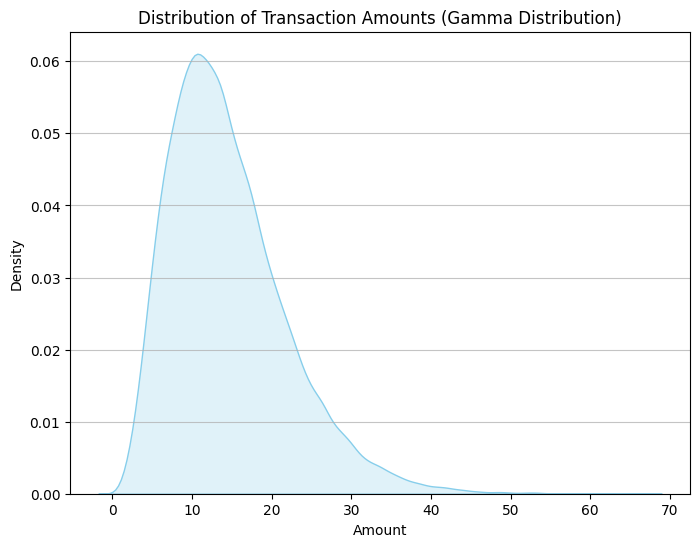

In [35]:
p, q, v = gg.params_

amount_dist = np.random.gamma(shape=p, scale=v, size=100000)

plt.figure(figsize=(8, 6))
sns.kdeplot(amount_dist, fill=True, color='skyblue')
plt.title('Distribution of Transaction Amounts (Gamma Distribution)')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Survival Analysis

tenure = cutoff_date (calculated above) - first transaction date (day units) </p>
true_lifetime_days = ground truth life time duration </p>
residual_days = true_lifetime_days - tenure

In [20]:
hist = transactions[transactions['transaction_date'] <= cutoff_date]

survival_df = hist.groupby('customer_id').agg(
    first_txn_date=('transaction_date', 'min'),
    num_transactions=('transaction_date', 'count'),
    avg_amount=('amount', 'mean')
).reset_index()

survival_df['tenure'] = (cutoff_date - survival_df['first_txn_date']).dt.days

survival_df = survival_df.merge(customers[['customer_id', 'true_lifetime_days']], on='customer_id', how='left')

survival_df['residual_days'] = survival_df['true_lifetime_days'] - survival_df['tenure']

observation_end = transactions['transaction_date'].max()
max_possible_residual = (observation_end - survival_df['first_txn_date']).dt.days - survival_df['tenure']
survival_df['event'] = (survival_df['residual_days'] < max_possible_residual).astype(int)

# Remove customers who churned before the cutoff (true lifetime days < tenure)
# entry_col='tenure' in the CPH fit corrects for this selection statistically
n_before = len(survival_df)
survival_df = survival_df[survival_df['residual_days'] > 0].copy()
print(f"Dropped {n_before - len(survival_df)} customers who churned before cutoff (unobservable)")

# Drop helper columns; KEEP true_lifetime_days as duration_col and tenure as entry_col
survival_df = survival_df.drop(columns=['first_txn_date', 'residual_days'])

print(f"Shape: {survival_df.shape}")
print(f"Event rate: {survival_df['event'].mean():.2%}")
display(survival_df.head())

Dropped 938 customers who churned before cutoff (unobservable)
Shape: (1326, 6)
Event rate: 46.00%


,customer_id,num_transactions,avg_amount,tenure,true_lifetime_days,event
0,C00000,3,126.633333,22,204,0
1,C00001,11,56.435455,199,365,0
2,C00002,11,82.785455,43,48,1
4,C00006,1,20.200000,28,117,1
5,C00007,5,116.926000,52,321,0


In [21]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(
    survival_df.drop(columns=['customer_id']),
    duration_col='true_lifetime_days',
    event_col='event',
    # left truncation to avoid survival bias
    entry_col='tenure'
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1326 total observations, 716 right-censored observations>
             duration col = 'true_lifetime_days'
                event col = 'event'
                entry col = 'tenure'
      baseline estimation = breslow
   number of observations = 1326
number of events observed = 610
   partial log-likelihood = -3823.63
         time fit was run = 2026-04-23 17:01:59 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
num_transactions  0.01      1.01      0.00            0.00            0.02                1.00                1.02
avg_amount        0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                  cmp to    z      p  -log2(p)
covariate                                     
num_transactions    0.00 3.13 <0.005      9.15
avg_amount          0.00 1.00   0.32      1.66
---
Concordance = 0.41
Partial AIC = 7651.25
log-likelihood ratio test = 9.85 on 2 df
-log2(p) of ll-ratio test = 7.10

The survival analysis chart below shows the estimated probability that a customer remains active after the cutoff date, conditional on having already survived up to the cutoff (i.e., left truncation is applied). The curve represents a forward-looking survival function from the cutoff point onward.

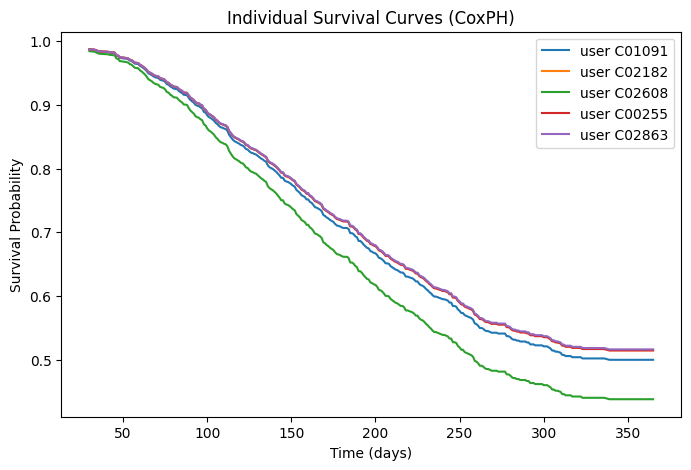

In [22]:
sample_users = survival_df.sample(5, random_state=1)

plt.figure(figsize=(8, 5))

for _, row in sample_users.iterrows():
    surv_fn = cph.predict_survival_function(row[['num_transactions', 'avg_amount', 'tenure']].to_frame().T)
    plt.plot(surv_fn.index, surv_fn.values.flatten(), label=f"user {(row.customer_id)}")

plt.title("Individual Survival Curves (CoxPH)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [79]:
# Business-level assumption — only the discount rate is external; profit is derived per customer
ANNUAL_IRR: float = 0.10


def get_customer_profile(customer_id: str) -> pd.DataFrame:
    """Derive CoxPH inputs from transaction history for a given customer."""
    hist = transactions[
        (transactions['customer_id'] == customer_id) &
        (transactions['transaction_date'] <= cutoff_date)
    ]
    if hist.empty:
        raise ValueError(f"No transactions found for customer '{customer_id}' up to cutoff date.")

    first_txn = hist['transaction_date'].min()
    profile = pd.DataFrame({
        'num_transactions': [len(hist)],
        'avg_amount':       [hist['amount'].mean()],
        'tenure':           [(cutoff_date - first_txn).days],
    })
    return profile


def get_monthly_profit(customer_id: str, num_months: int) -> float:
    """
    Estimate monthly profit using Gamma-Gamma expected order value and
    BG/NBD predicted purchase rate (both fitted on data up to cutoff_date).

    monthly_profit = expected_avg_order_value × (predicted_purchases_3M / 3)
    """
    row = lifetime_df.loc[lifetime_df.index == customer_id]
    if row.empty or pd.isna(row['expected_avg_order_value'].iloc[0]):
        # fallback for one-time buyers excluded from Gamma-Gamma fit
        hist = transactions[
            (transactions['customer_id'] == customer_id) &
            (transactions['transaction_date'] <= cutoff_date)
        ]
        return float(hist['amount'].mean())

    avg_order_value = float(row['expected_avg_order_value'].iloc[0])
    
    purchases_per_month = list()
    for n in range(1, num_months+1):
        monthly_purchases = bg.predict(
            t=n*30,
            frequency=row['frequency'].iloc[0],
            recency=row['recency'].iloc[0],
            T=row['T'].iloc[0]) - bg.predict(
                t=(n-1)*30,
                frequency=row['frequency'].iloc[0],
                recency=row['recency'].iloc[0],
                T=row['T'].iloc[0]
            ) 
        purchases_per_month.append(monthly_purchases)

    return avg_order_value * np.array(purchases_per_month)


def get_payback_df(customer_id: str, num_months: int) -> pd.DataFrame:
    profile = get_customer_profile(customer_id)
    tenure = int(profile['tenure'].iloc[0])
    irr = ANNUAL_IRR / 12
    monthly_profit = get_monthly_profit(customer_id, num_months)

    surv = cph.predict_survival_function(profile, conditional_after=[tenure])
    cohort_df = pd.concat([pd.DataFrame([1.00]), round(surv, 2)]).rename(columns={0: 'Survival Probability'})

    targets = [n * 30 for n in range(num_months + 1)]
    cohort_df = cohort_df.loc[[cohort_df.index[cohort_df.index <= t].max() for t in targets]]
    
    cohort_df['Month'] = range(num_months + 1)
    cohort_df['Monthly Profit'] = np.round(np.concatenate(([0.0], monthly_profit)), 2)
    cohort_df['Avg Expected Monthly Profit'] = round(cohort_df['Survival Probability'] * cohort_df['Monthly Profit'], 2)
    cohort_df['NPV of Avg Expected Monthly Profit'] = np.round(
        cohort_df['Avg Expected Monthly Profit'] / ((1 + irr) ** cohort_df['Month']), 2
    )
    cohort_df['Cumulative NPV'] = cohort_df['NPV of Avg Expected Monthly Profit'].cumsum()
    return cohort_df.set_index('Month')


customer_id = 'C01329'
get_payback_df(customer_id, 3)

,Survival Probability,Monthly Profit,Avg Expected Monthly Profit,NPV of Avg Expected Monthly Profit,Cumulative NPV
Month,,,,,
0,1.00,0.00,0.00,0.00,0.00
1,0.94,294.59,276.91,274.62,274.62
2,0.86,266.74,229.40,225.62,500.24
3,0.78,246.38,192.18,187.45,687.69


prompt:
- with .ipynb maintain intact
- build different classes given in pdf
- build  charts associated with each class
- a .py to define strategy?